# Setup

## Load packages

In [1]:
# Load up necessary packages. 
import os
import glob
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Import my custom utils.
import utils
importlib.reload(utils)

<module 'utils' from '/tscc/projects/ps-yeolab3/kflanagan/plip_plop/V2_feature_vectors/utils.py'>

## Load results

In [2]:
INPUT_DIR = "/tscc/lustre/ddn/scratch/kflanagan/plip_plop_results/fv_processed_inputs/"

comparison_table = pd.read_csv("/tscc/nfs/home/kflanagan/projects/plip_plop/V2_feature_vectors/select_comparisons/encode_initial_30_comparisons.tsv", sep="\t")

In [3]:
comparison_table = comparison_table.loc[0:1]

# Organize data

In [4]:
comparison_data = {}
all_metadata = []

for comparison_id, row in comparison_table.iterrows():
    experiment_A = row["experiment_A"]
    experiment_B = row["experiment_B"]

    npz_file = os.path.join(INPUT_DIR, f"{experiment_A}_{experiment_B}.npz")

    if not os.path.exists(npz_file):
        print(f"Missing: {npz_file}")
        continue

    with np.load(npz_file) as data:
        ip_A = data["ip_signals_A"].astype(np.float32)
        in_A = data["in_signals_A"].astype(np.float32)
        ip_B = data["ip_signals_B"].astype(np.float32)
        in_B = data["in_signals_B"].astype(np.float32)

        n_windows = len(ip_A)

        if not (len(ip_A) == len(in_A) == len(ip_B) == len(in_B)):
            raise ValueError(f"Signal arrays do not match for comparison {comparison_id}.")

        comparison_data[comparison_id] = {
            "ip_A": ip_A,
            "in_A": in_A,
            "ip_B": ip_B,
            "in_B": in_B,
            "ip_A_library_sizes": data["ip_A_library_sizes"],
            "in_A_library_sizes": data["in_A_library_sizes"],
            "ip_B_library_sizes": data["ip_B_library_sizes"],
            "in_B_library_sizes": data["in_B_library_sizes"]
        }

        metadata = pd.DataFrame({
            "comparison_id": comparison_id,
            "window_idx": np.arange(n_windows),
            "category": row["category"],
            "experiment_A": experiment_A,
            "experiment_B": experiment_B,
            "chrom": data["chrom"],
            "start": data["start"],
            "end": data["end"],
            "strand": data["strand"],
            "region_id": data["region_id"],
            "block_number": data["block_number"]
        })

        all_metadata.append(metadata)

metadata = pd.concat(all_metadata, ignore_index=True)

print("Comparisons loaded:", len(comparison_data))
print("Total windows:", len(metadata))

Comparisons loaded: 2
Total windows: 30936


# C17 method

In [5]:
for comparison_id, comp in comparison_data.items():
    comp["ccc_xcorr"], comp["ccc_xcorr_lags"] = utils.calculate_fixed_ccc_cross_correlation(
        comp["ip_A"],
        comp["ip_B"],
        comp["ip_A_library_sizes"],
        comp["ip_B_library_sizes"],
        max_lag=30
    )

    print(
        comparison_id,
        comp["ccc_xcorr"].shape,
        "NaN:",
        np.isnan(comp["ccc_xcorr"]).sum()
    )

0 (17981, 2, 2, 61) NaN: 128
1 (12955, 2, 2, 61) NaN: 9372


In [6]:
metadata["ccc_xcorr_max"] = np.nan
metadata["ccc_xcorr_best_lag"] = np.nan
metadata["ccc_xcorr_zero"] = np.nan
metadata["ccc_xcorr_gain"] = np.nan

for comparison_id, comp in comparison_data.items():
    xcorr = comp["ccc_xcorr"]
    lags = comp["ccc_xcorr_lags"]

    with np.errstate(invalid="ignore"):
        mean_curve = np.nanmean(xcorr, axis=(1, 2))

    valid = np.any(~np.isnan(mean_curve), axis=1)
    max_corr = np.full(len(mean_curve), np.nan)
    best_lag = np.full(len(mean_curve), np.nan)

    max_idx = np.nanargmax(mean_curve[valid], axis=1)
    max_corr[valid] = mean_curve[valid, max_idx]
    best_lag[valid] = lags[max_idx]

    zero_idx = np.where(lags == 0)[0][0]
    zero_corr = mean_curve[:, zero_idx]
    gain = max_corr - zero_corr

    comp["ccc_xcorr_mean_curve"] = mean_curve

    mask = metadata["comparison_id"] == comparison_id
    order = metadata.loc[mask, "window_idx"].to_numpy()

    metadata.loc[mask, "ccc_xcorr_max"] = max_corr[order]
    metadata.loc[mask, "ccc_xcorr_best_lag"] = best_lag[order]
    metadata.loc[mask, "ccc_xcorr_zero"] = zero_corr[order]
    metadata.loc[mask, "ccc_xcorr_gain"] = gain[order]

/scratch/kflanagan/job_12377905/ipykernel_368658/3366977698.py:11: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(xcorr, axis=(1, 2))


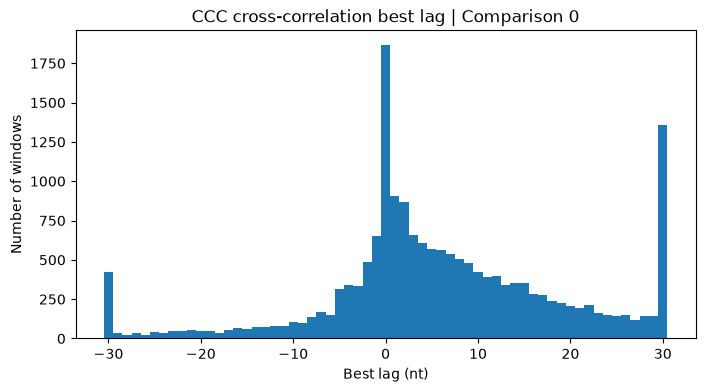

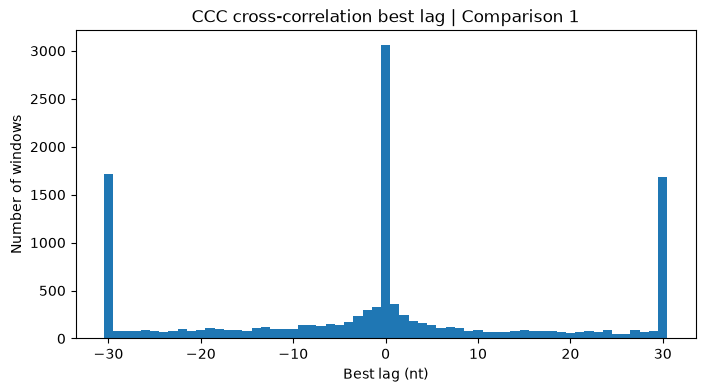

In [7]:
for comparison_id, group in metadata.groupby("comparison_id"):
    plt.figure(figsize=(8, 4))
    plt.hist(
        group["ccc_xcorr_best_lag"].dropna(),
        bins=np.arange(-30.5, 31.5, 1)
    )

    plt.xlabel("Best lag (nt)")
    plt.ylabel("Number of windows")
    plt.title(f"CCC cross-correlation best lag | Comparison {comparison_id}")
    plt.show()

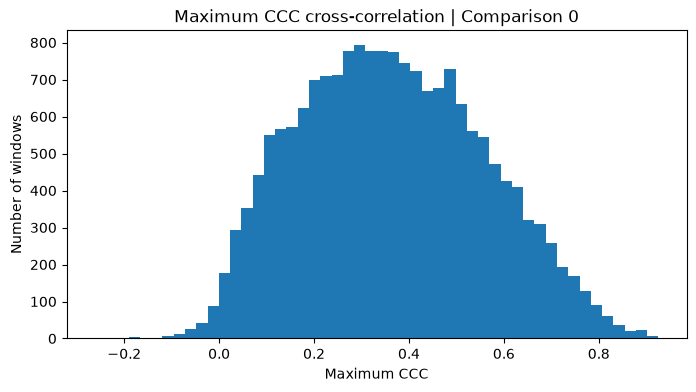

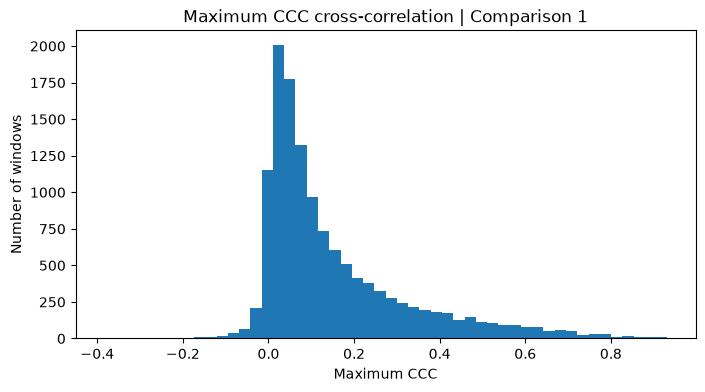

In [8]:
for comparison_id, group in metadata.groupby("comparison_id"):
    plt.figure(figsize=(8, 4))
    plt.hist(group["ccc_xcorr_max"].dropna(), bins=50)

    plt.xlabel("Maximum CCC")
    plt.ylabel("Number of windows")
    plt.title(f"Maximum CCC cross-correlation | Comparison {comparison_id}")
    plt.show()

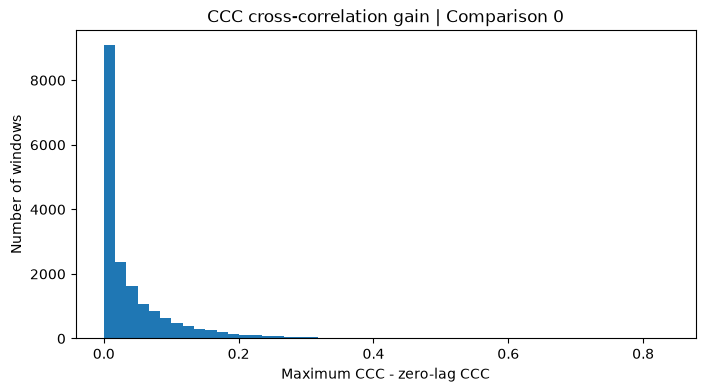

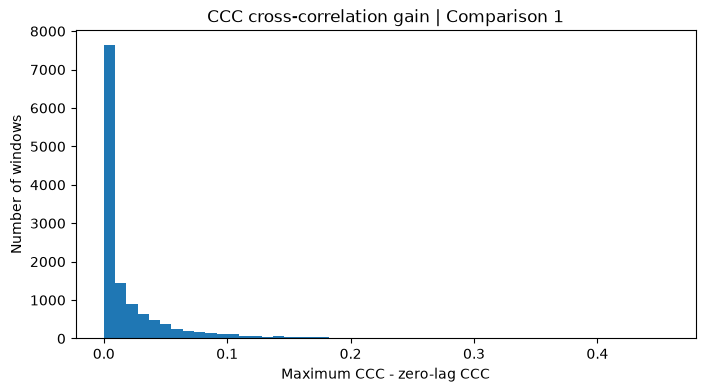

In [9]:
for comparison_id, group in metadata.groupby("comparison_id"):
    plt.figure(figsize=(8, 4))
    plt.hist(group["ccc_xcorr_gain"].dropna(), bins=50)

    plt.xlabel("Maximum CCC - zero-lag CCC")
    plt.ylabel("Number of windows")
    plt.title(f"CCC cross-correlation gain | Comparison {comparison_id}")
    plt.show()

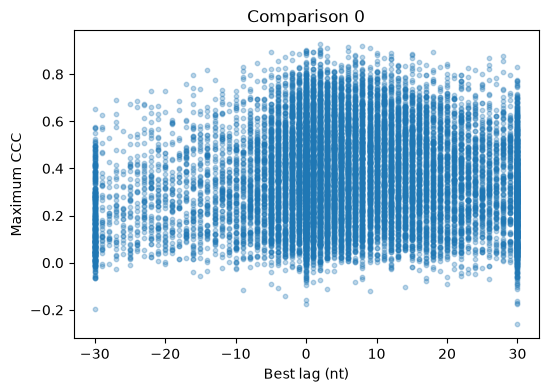

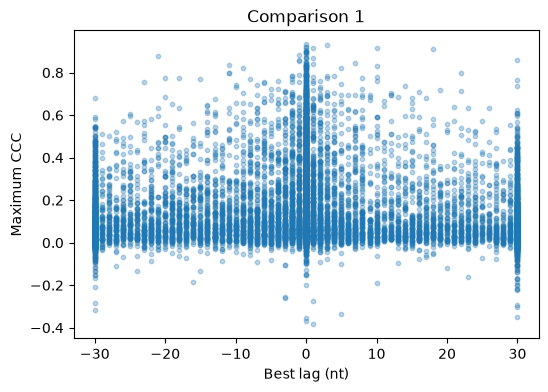

In [10]:
for comparison_id, group in metadata.groupby("comparison_id"):
    plt.figure(figsize=(6, 4))
    plt.scatter(
        group["ccc_xcorr_best_lag"],
        group["ccc_xcorr_max"],
        alpha=0.3,
        s=10
    )

    plt.xlabel("Best lag (nt)")
    plt.ylabel("Maximum CCC")
    plt.title(f"Comparison {comparison_id}")
    plt.show()

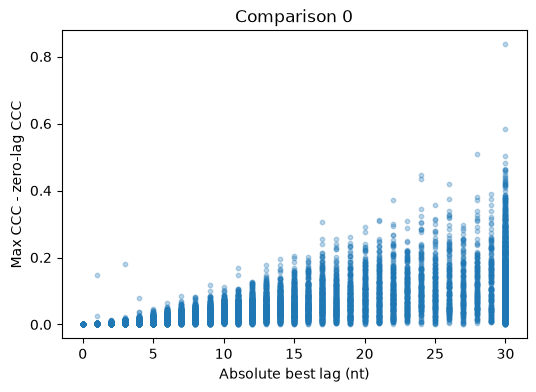

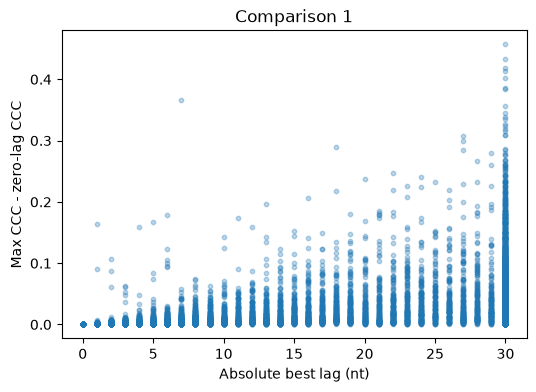

In [11]:
for comparison_id, group in metadata.groupby("comparison_id"):
    plt.figure(figsize=(6, 4))
    plt.scatter(
        np.abs(group["ccc_xcorr_best_lag"]),
        group["ccc_xcorr_gain"],
        alpha=0.3,
        s=10
    )

    plt.xlabel("Absolute best lag (nt)")
    plt.ylabel("Max CCC - zero-lag CCC")
    plt.title(f"Comparison {comparison_id}")
    plt.show()

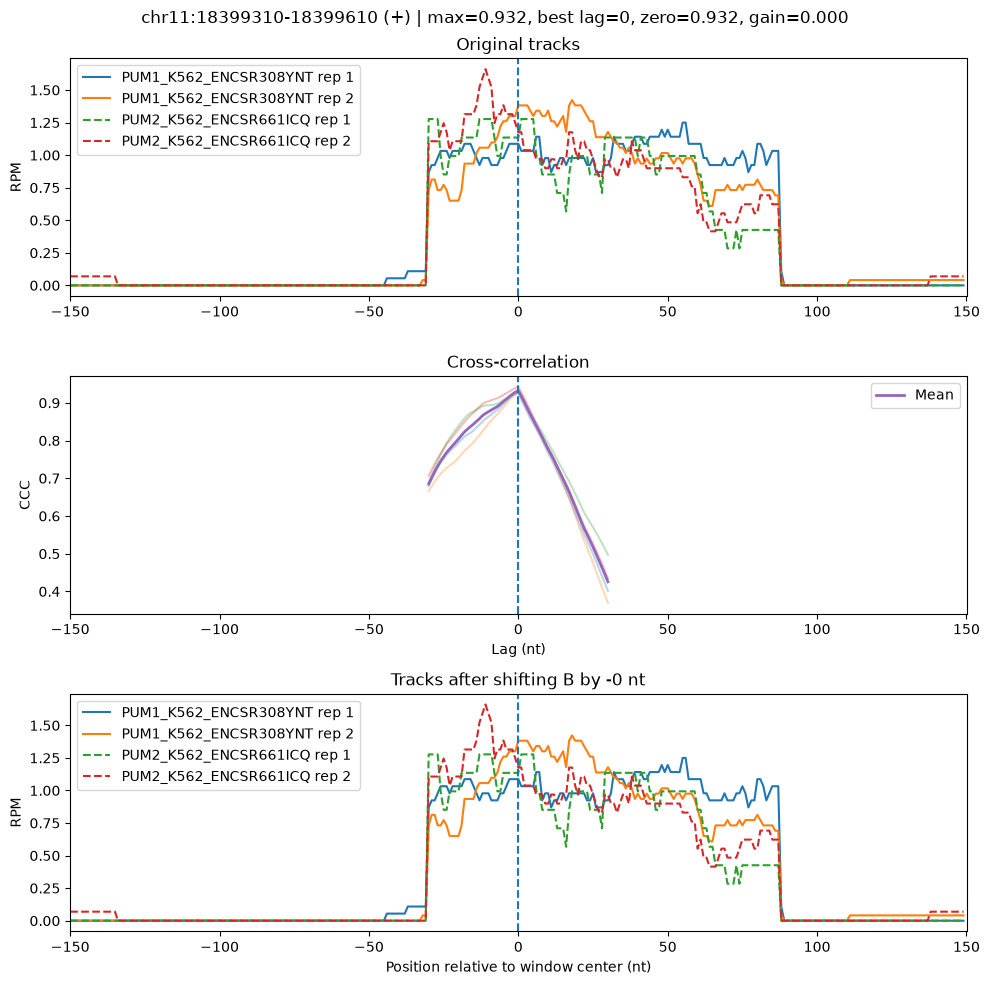

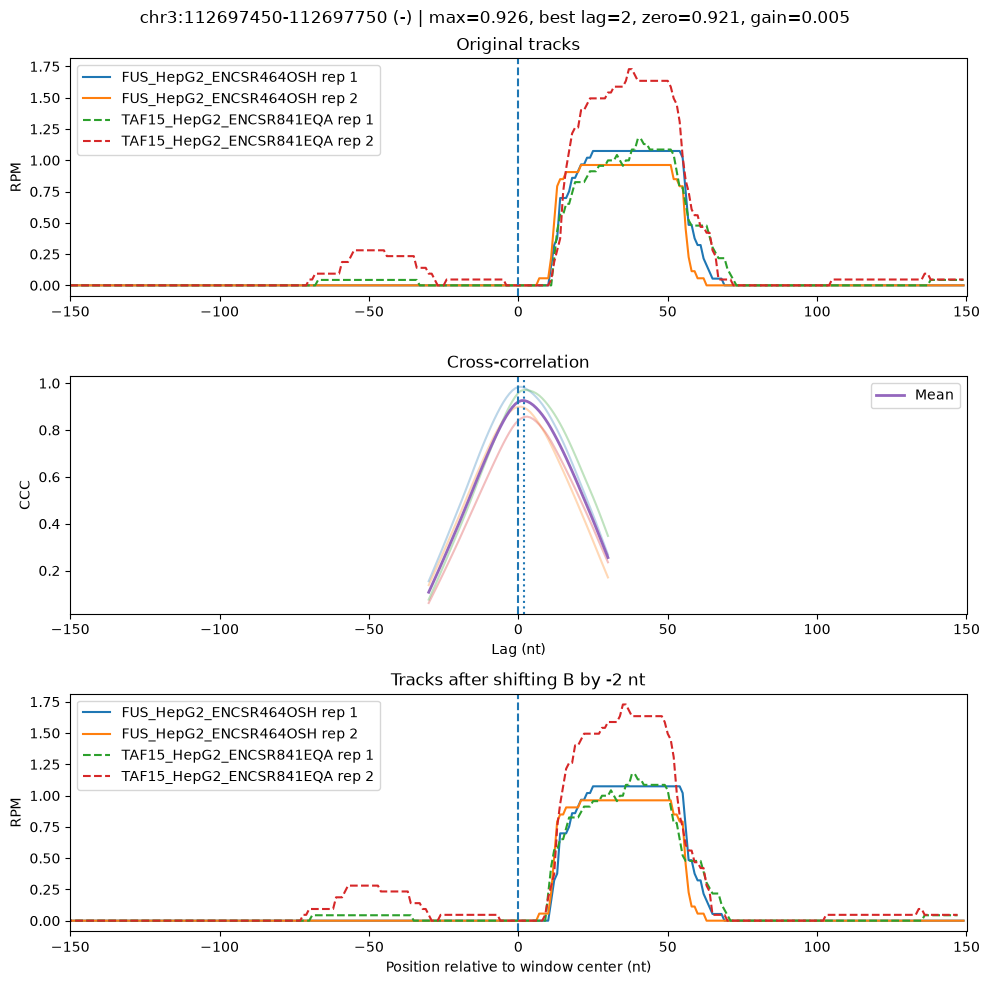

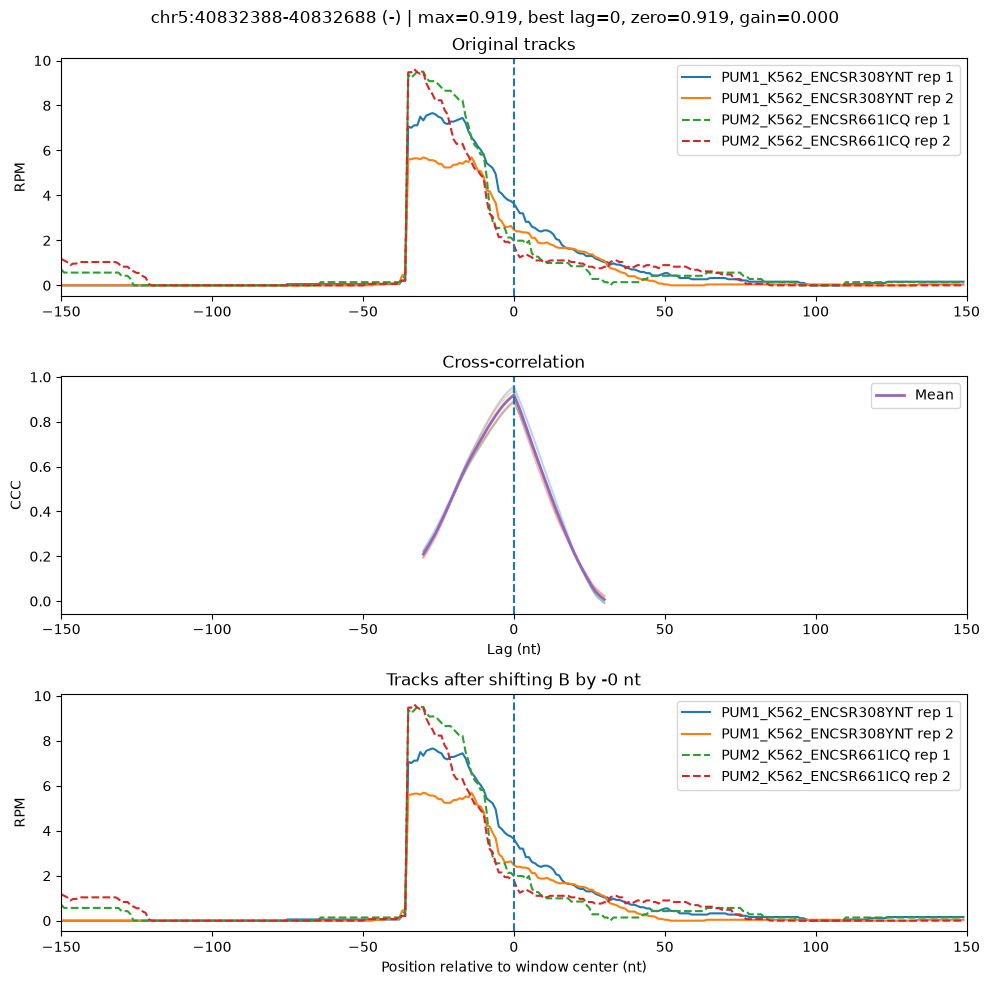

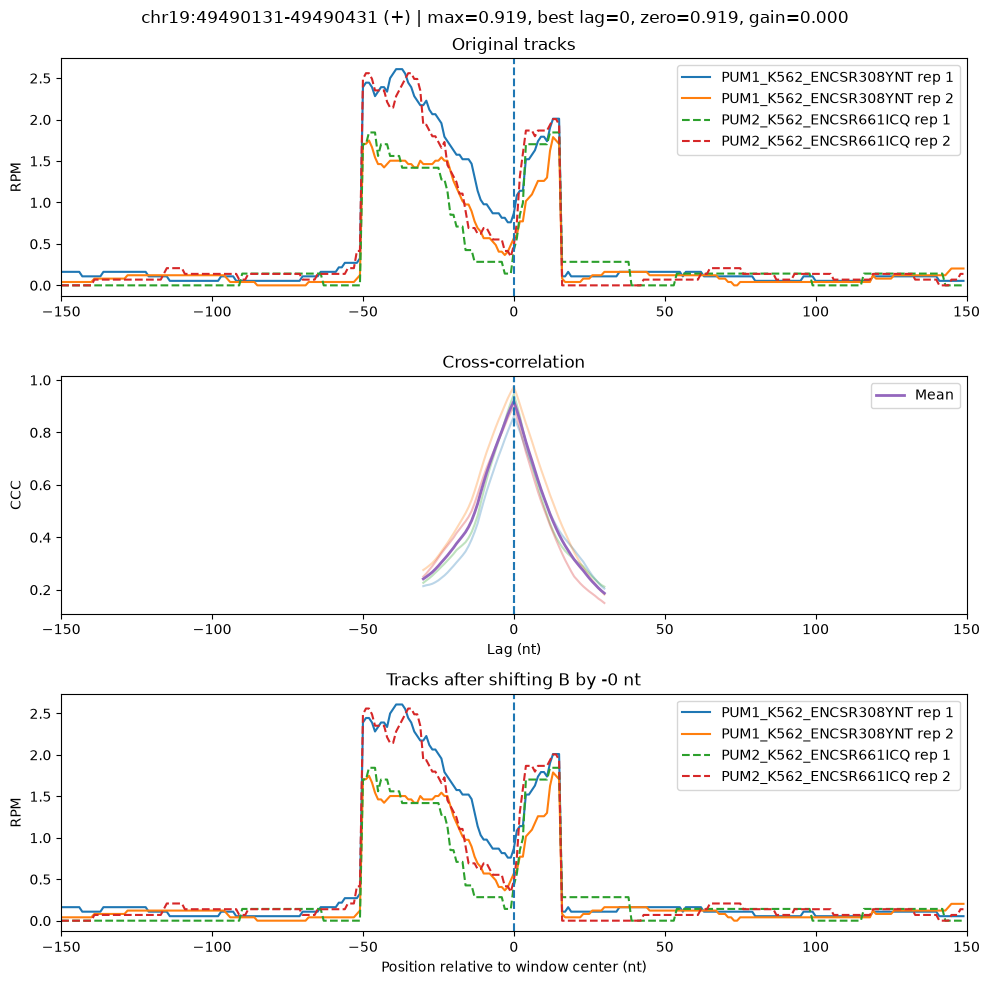

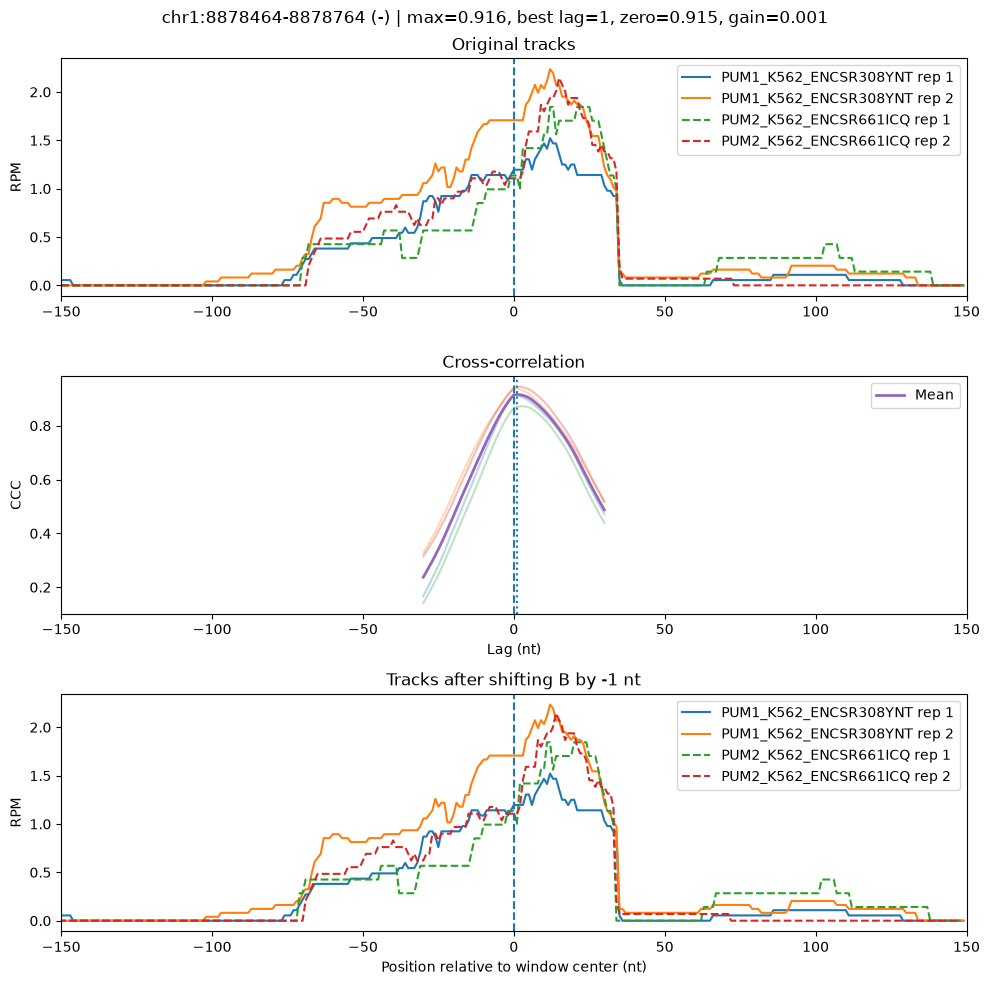

In [12]:
near_zero = metadata[
    metadata["ccc_xcorr_best_lag"].abs() <= 2
].nlargest(5, "ccc_xcorr_max")

for _, row in near_zero.iterrows():
    utils.plot_xcorr_window(row, comparison_data, "ccc_xcorr", rpm=True)

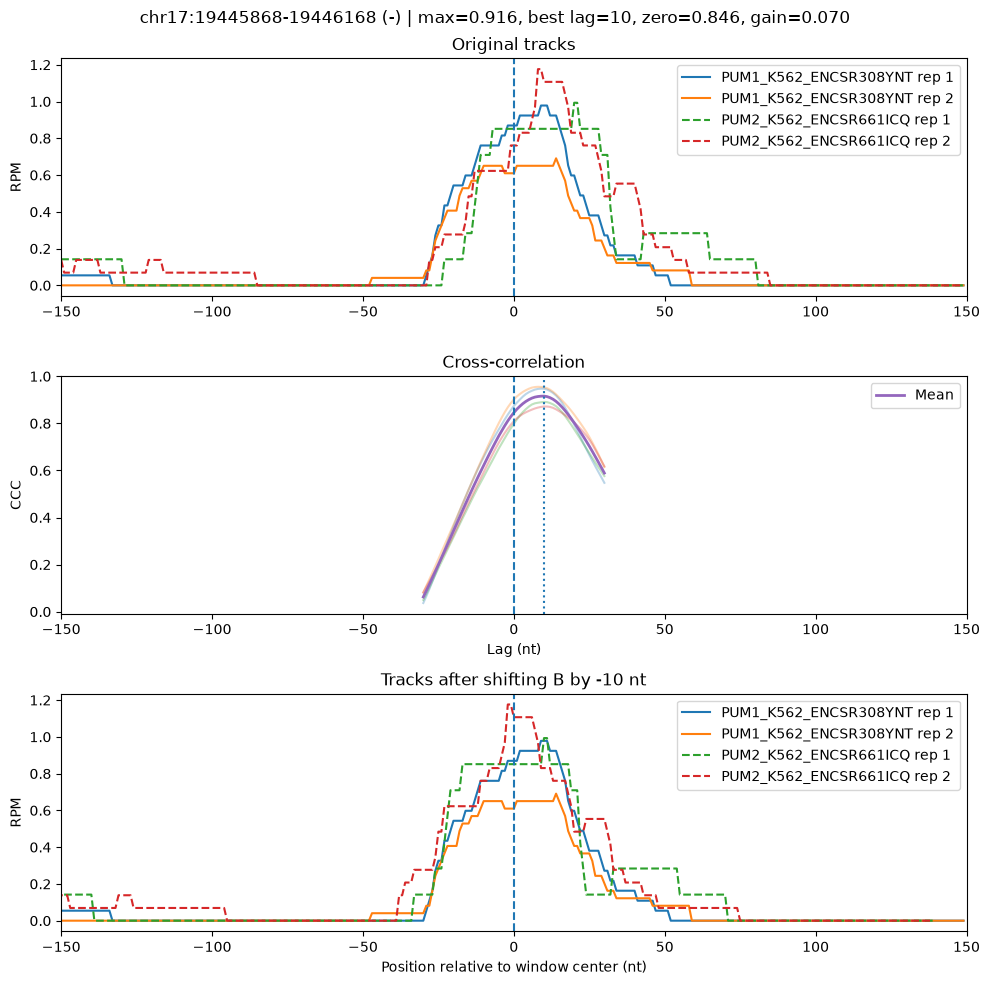

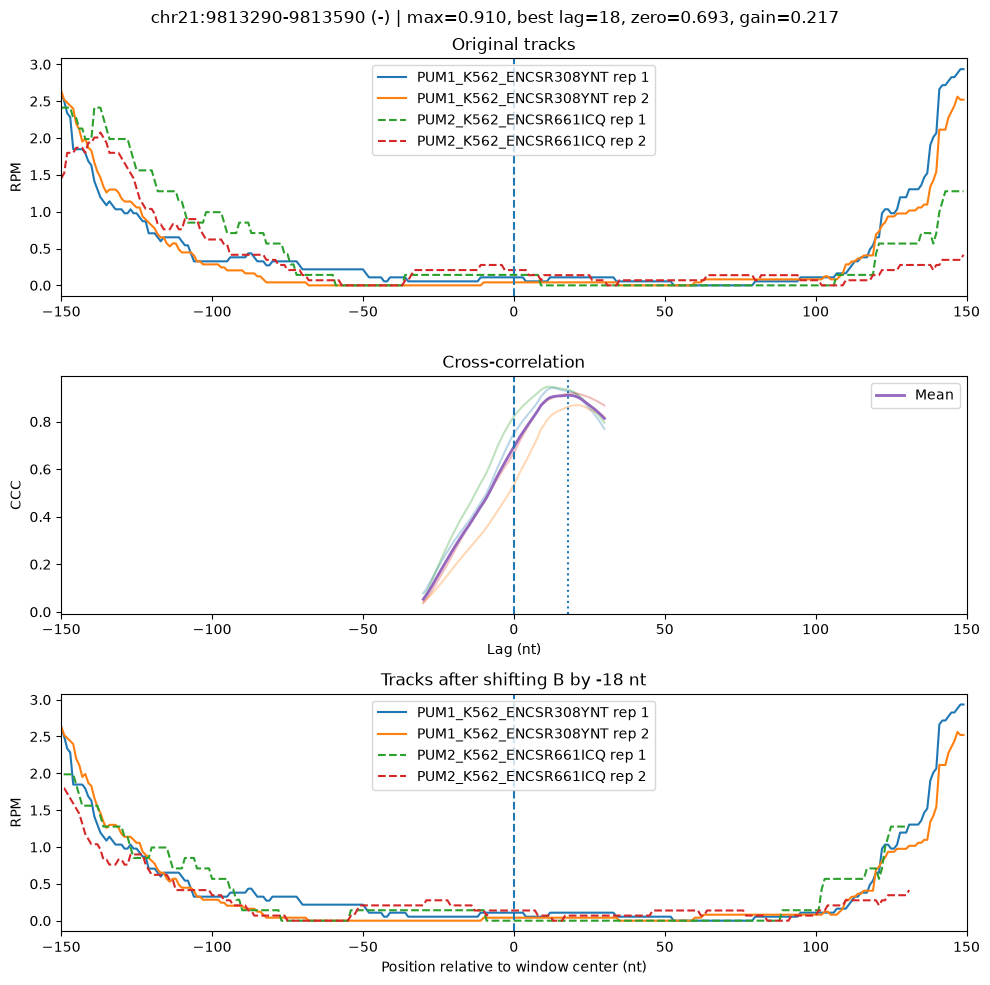

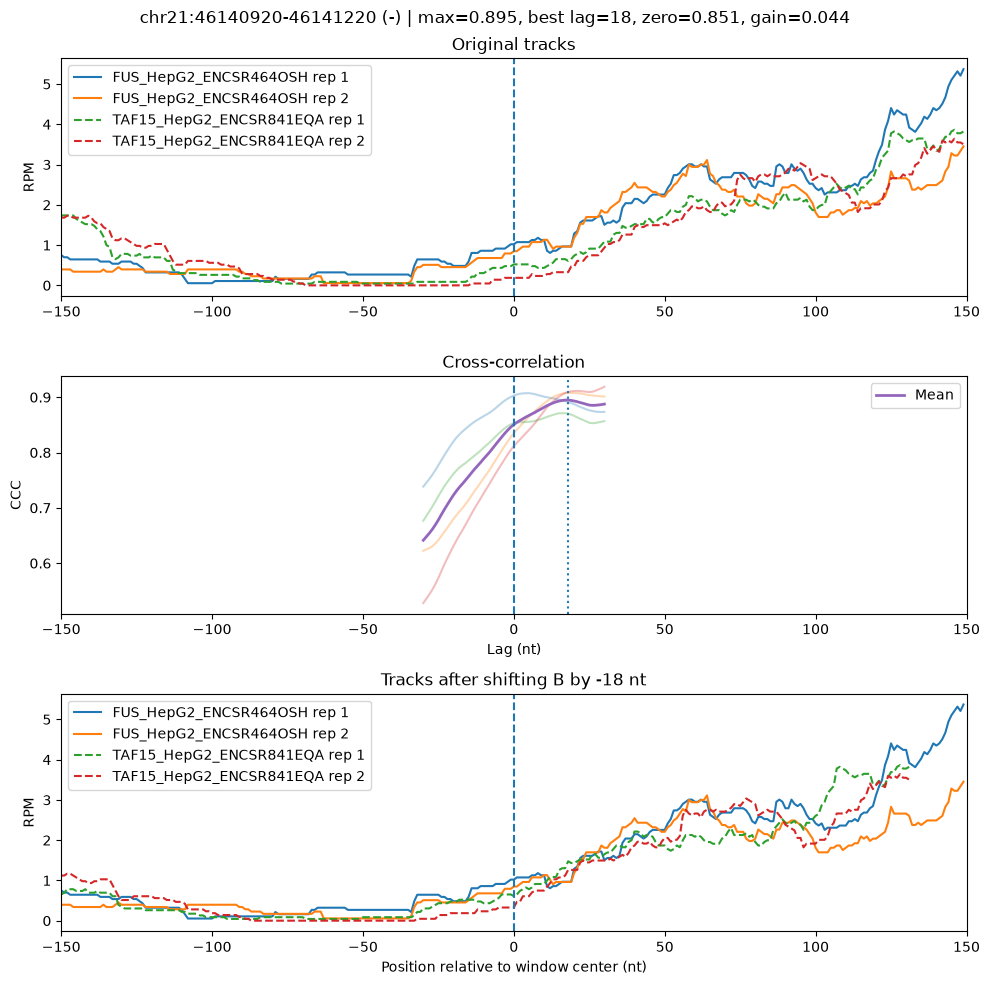

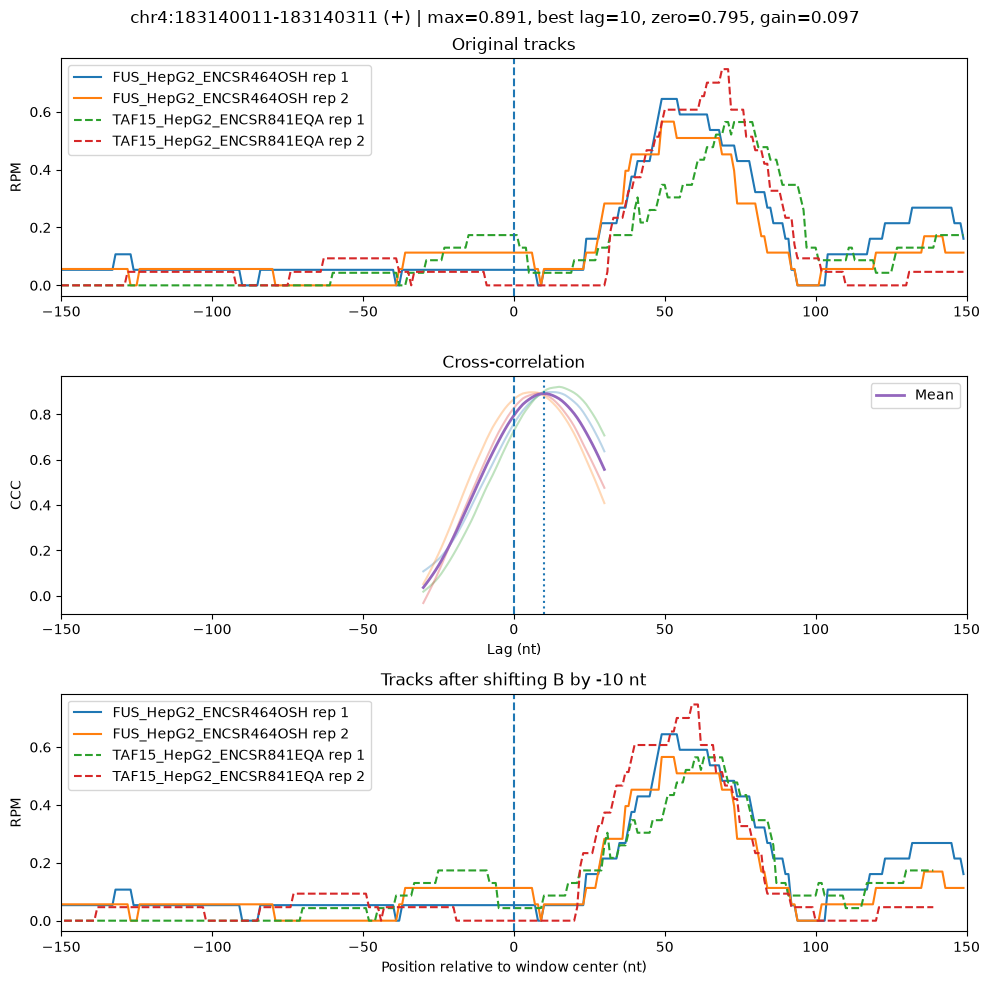

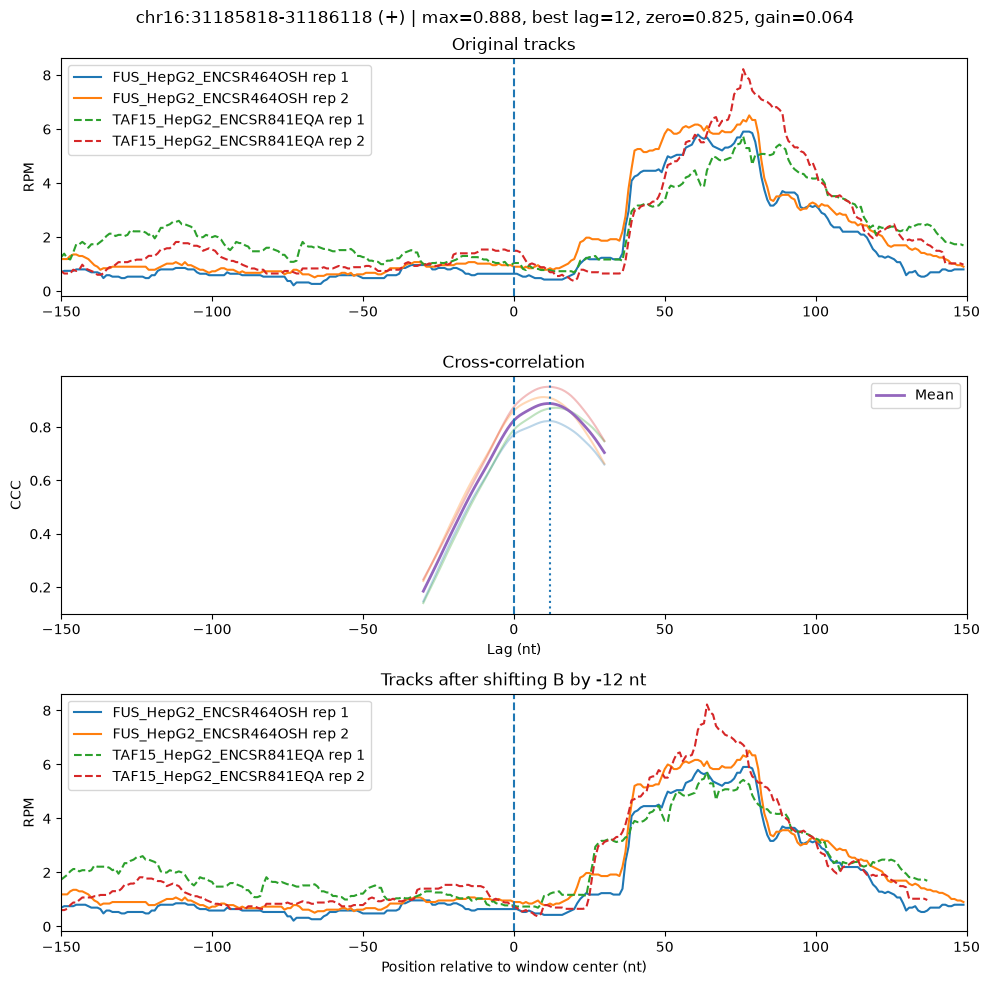

In [13]:
large_lag = metadata[
    metadata["ccc_xcorr_best_lag"].abs() >= 10
].nlargest(5, "ccc_xcorr_max")

for _, row in large_lag.iterrows():
    utils.plot_xcorr_window(row, comparison_data, "ccc_xcorr", rpm=True)

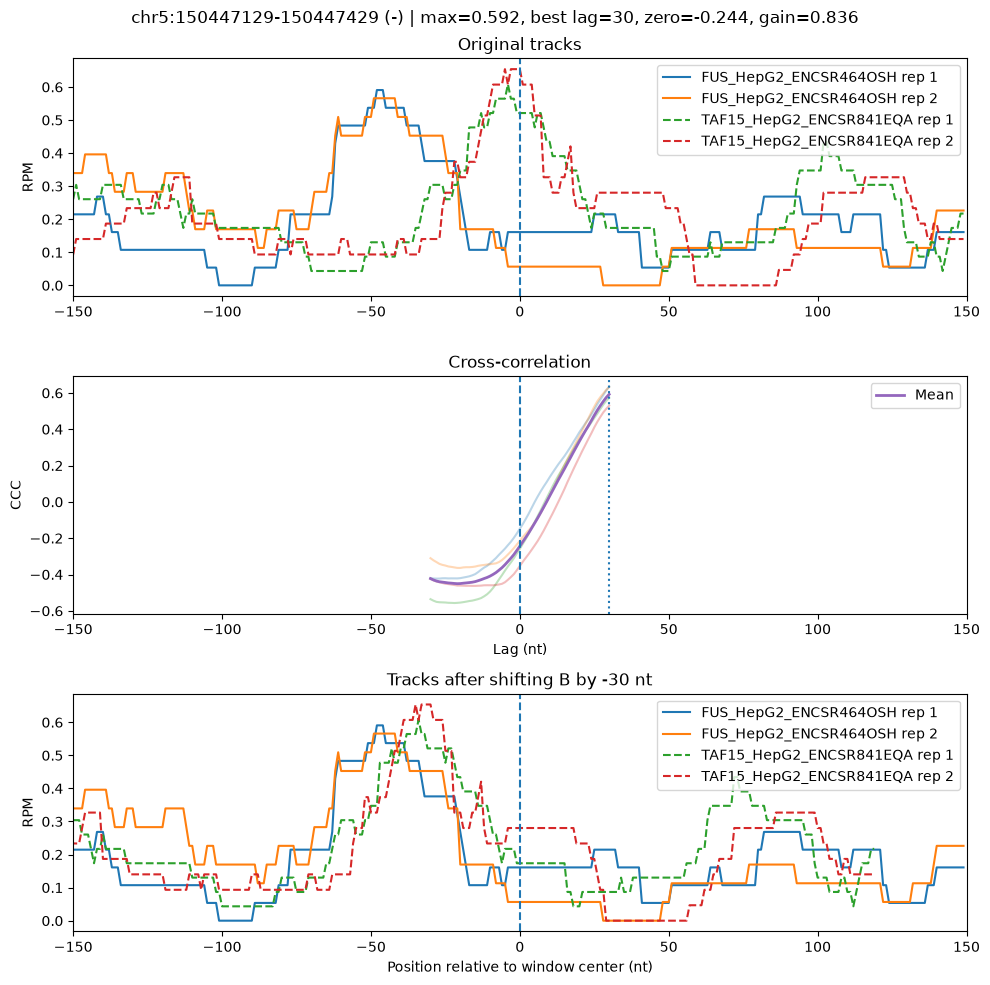

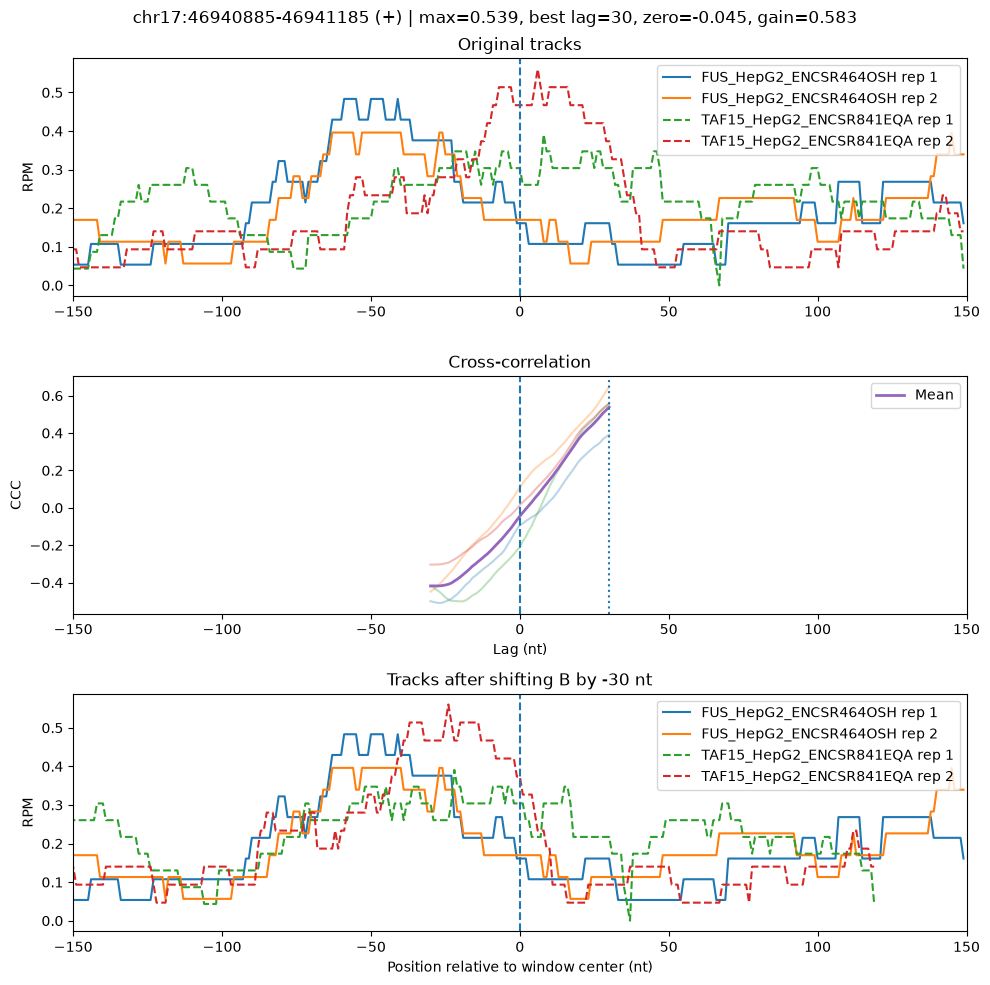

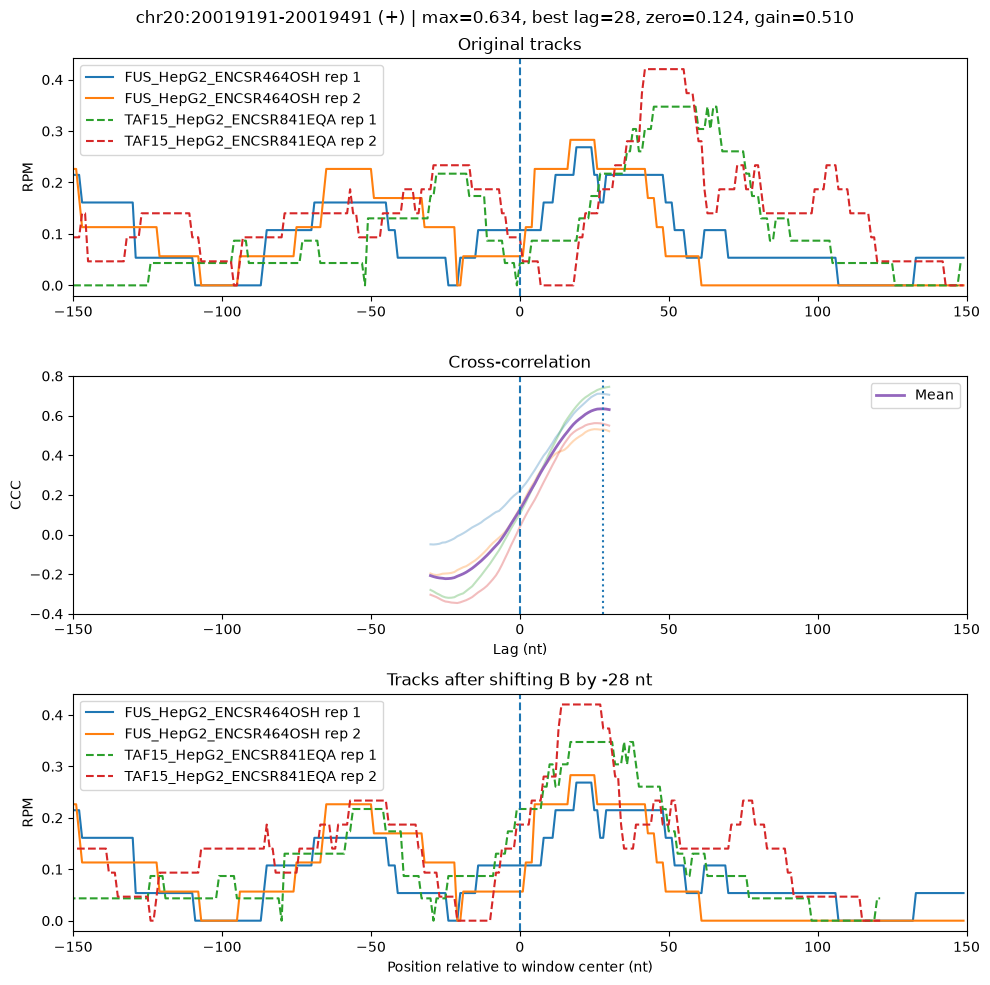

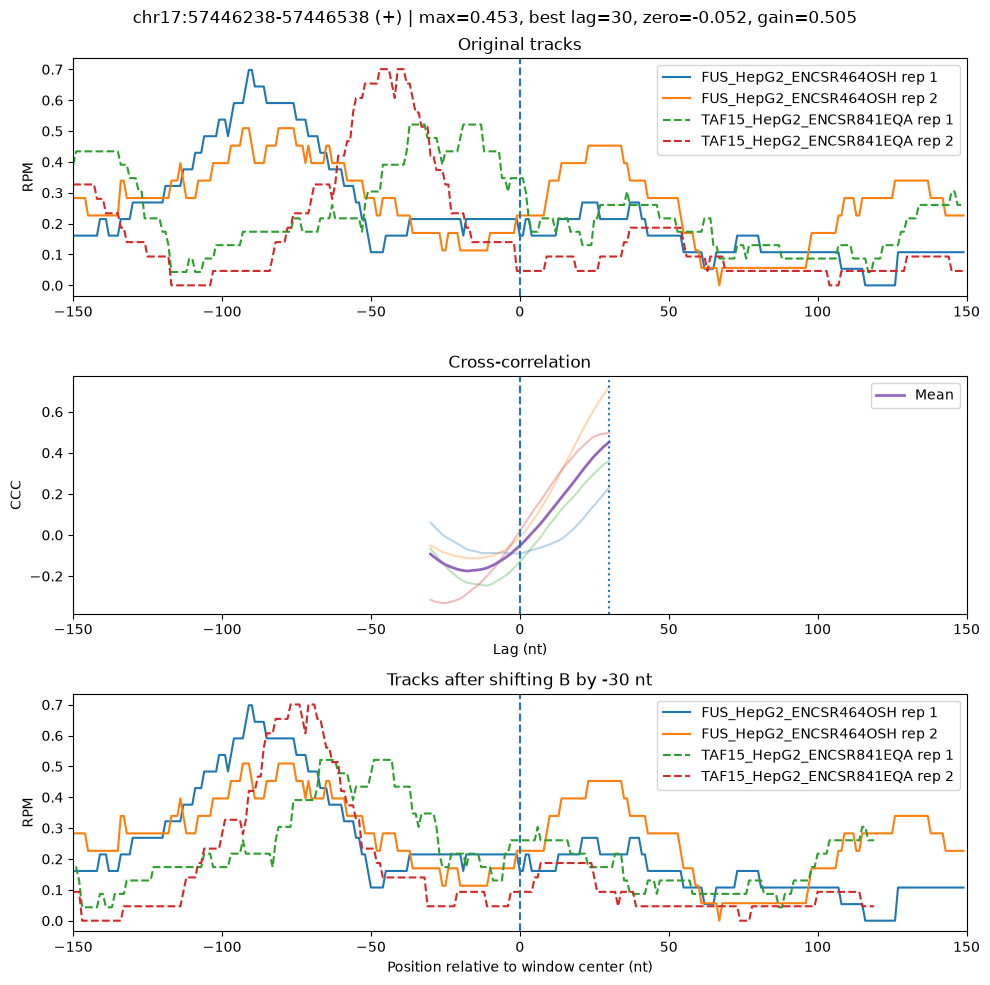

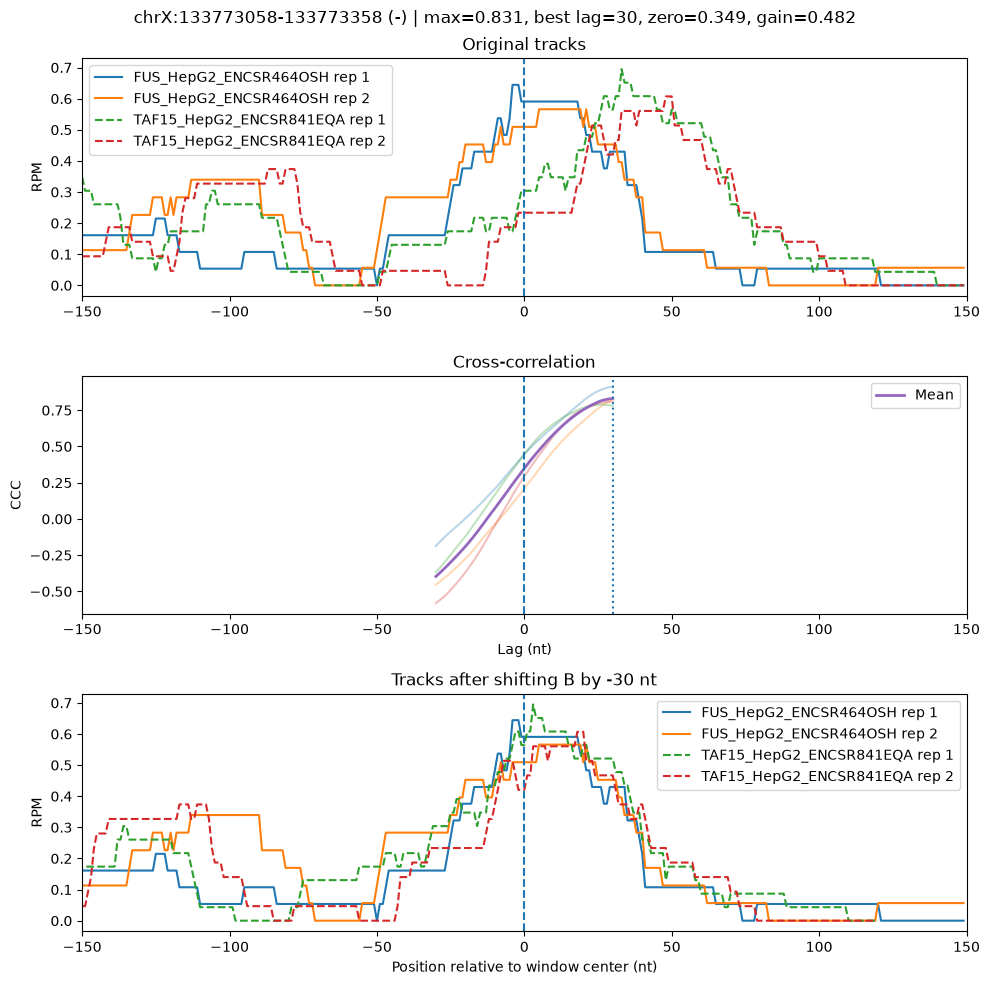

In [14]:
high_gain = metadata.nlargest(5, "ccc_xcorr_gain")

for _, row in high_gain.iterrows():
    utils.plot_xcorr_window(row, comparison_data, "ccc_xcorr", rpm=True)

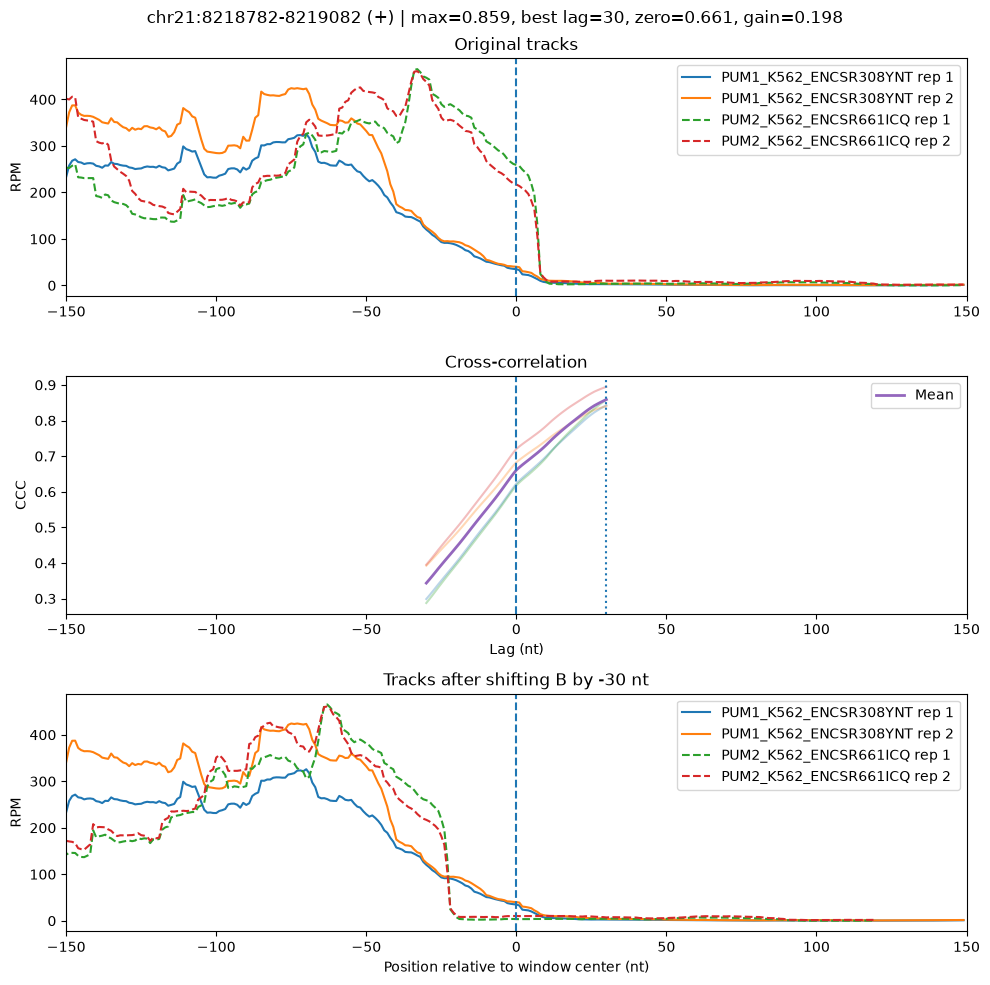

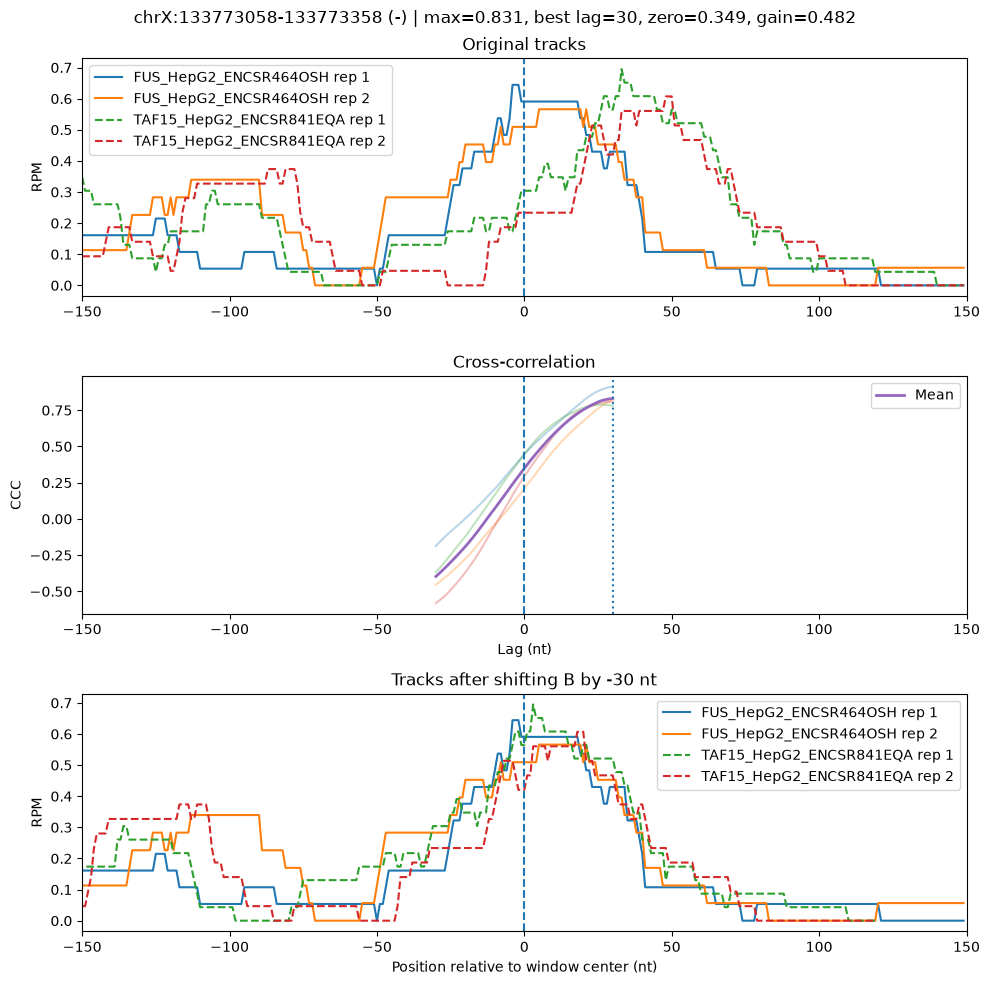

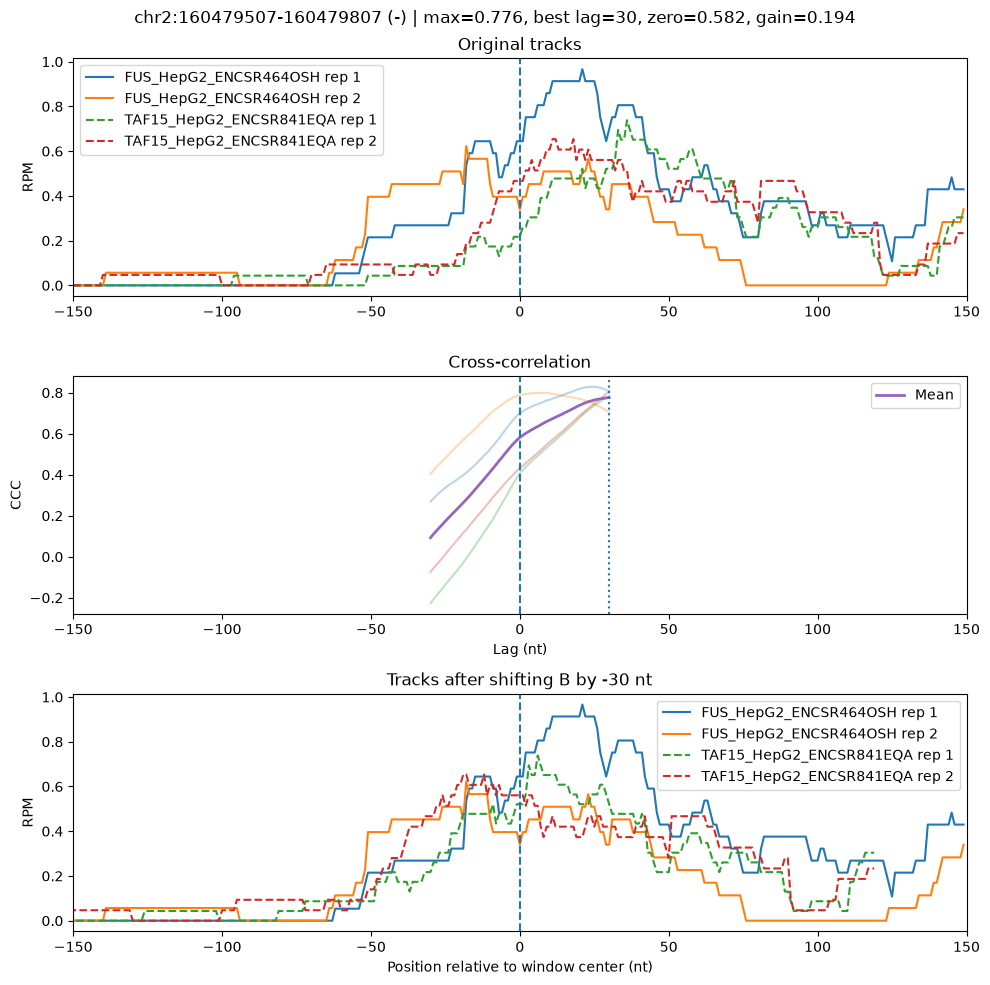

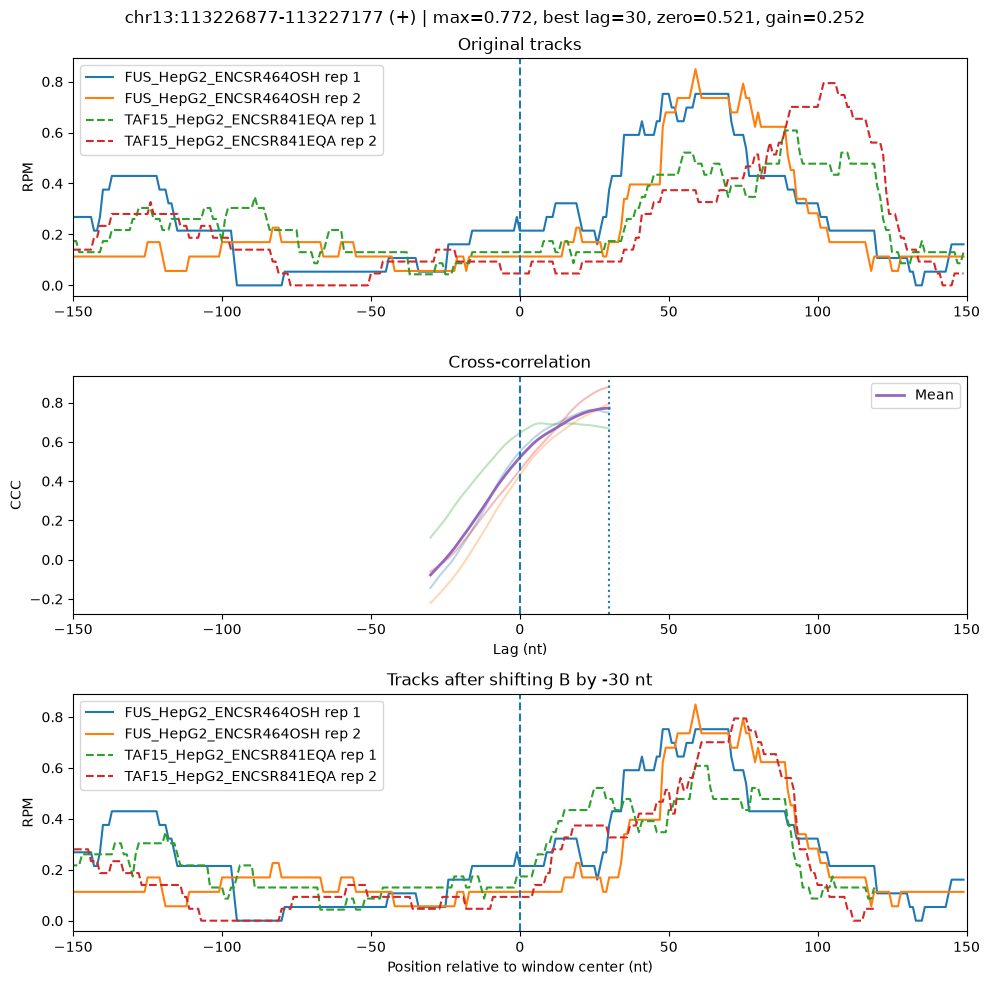

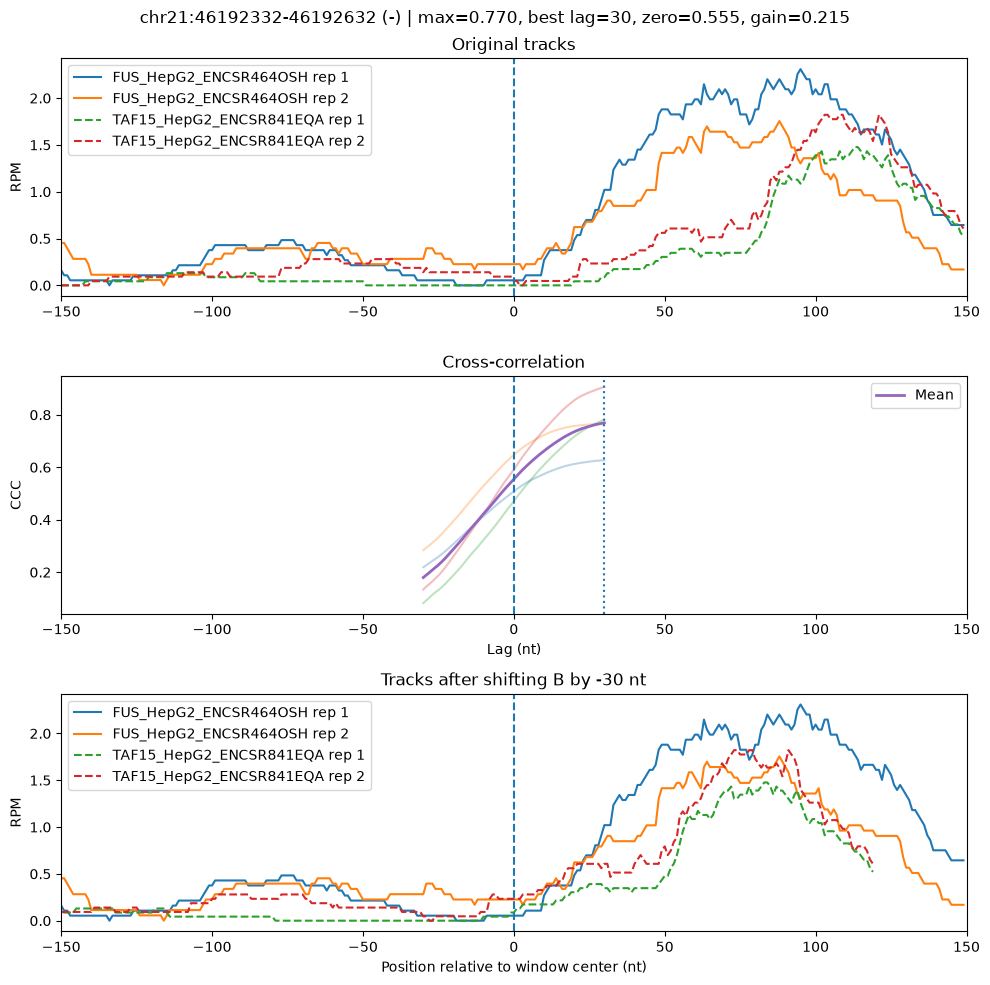

In [15]:
boundary = metadata[
    metadata["ccc_xcorr_best_lag"].abs() == 30
].nlargest(5, "ccc_xcorr_max")

for _, row in boundary.iterrows():
    utils.plot_xcorr_window(row, comparison_data, "ccc_xcorr", rpm=True)